In [1]:
import pandas as pd
from sklearn.impute import SimpleImputer
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("loan_approval_data.csv")

In [3]:
df.sample(10)

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
390,391.0,12636.0,984.0,Self-employed,45.0,Married,3.0,592.0,1.0,0.21,5141.0,1485.0,23889.0,48.0,Business,Rural,Graduate,Male,Private,No
975,976.0,19327.0,NaN,Salaried,36.0,Single,3.0,596.0,0.0,0.59,5935.0,510.0,9831.0,24.0,Business,Semiurban,Graduate,Male,Private,No
131,132.0,9526.0,NaN,Contract,25.0,Married,0.0,602.0,4.0,0.23,17182.0,28546.0,39501.0,24.0,Business,Semiurban,Graduate,Male,MNC,No
853,854.0,14999.0,7123.0,Contract,33.0,Married,2.0,573.0,4.0,0.14,13426.0,NaN,6738.0,48.0,Home,Urban,Graduate,Female,NaN,No
171,172.0,16243.0,545.0,Contract,43.0,NaN,1.0,650.0,2.0,0.14,2397.0,21209.0,25373.0,12.0,Home,Semiurban,Graduate,Female,Private,No
389,390.0,19450.0,6573.0,Unemployed,46.0,Married,2.0,770.0,2.0,0.16,8095.0,8680.0,2832.0,12.0,Home,Rural,Graduate,Male,Unemployed,Yes
808,809.0,13246.0,2349.0,Contract,41.0,Single,2.0,598.0,3.0,0.57,3146.0,13176.0,18769.0,24.0,Business,Semiurban,Graduate,Male,Private,No
38,39.0,13016.0,9900.0,Salaried,46.0,Married,3.0,567.0,0.0,0.52,4483.0,12807.0,NaN,48.0,Car,NaN,Not Graduate,Male,Business,No
957,958.0,12998.0,1179.0,Self-employed,33.0,Married,3.0,767.0,0.0,0.55,6044.0,18013.0,39278.0,12.0,Personal,Rural,Graduate,Male,Private,No
633,634.0,10472.0,9556.0,Salaried,22.0,Single,2.0,668.0,1.0,0.29,2083.0,NaN,9507.0,12.0,Personal,Rural,Not Graduate,Female,MNC,Yes


In [7]:
df.info()
df.isnull().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        1000 non-null   float64
 1   Applicant_Income    1000 non-null   float64
 2   Coapplicant_Income  1000 non-null   float64
 3   Employment_Status   1000 non-null   object 
 4   Age                 1000 non-null   float64
 5   Marital_Status      1000 non-null   object 
 6   Dependents          1000 non-null   float64
 7   Credit_Score        1000 non-null   float64
 8   Existing_Loans      1000 non-null   float64
 9   DTI_Ratio           1000 non-null   float64
 10  Savings             1000 non-null   float64
 11  Collateral_Value    1000 non-null   float64
 12  Loan_Amount         1000 non-null   float64
 13  Loan_Term           1000 non-null   float64
 14  Loan_Purpose        1000 non-null   object 
 15  Property_Area       1000 non-null   object 
 16  Educati

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,501.220000,10852.571579,5082.455789,39.971579,1.474737,676.033684,1.950526,0.347263,9940.452632,24802.792632,20522.825263,48.000000
std,282.267965,4933.339492,2868.563488,10.857445,1.077058,69.537662,1.370603,0.140683,5712.189236,13982.086562,11212.555805,23.630794
min,1.000000,2009.000000,1.000000,21.000000,0.000000,550.000000,0.000000,0.100000,65.000000,36.000000,1015.000000,12.000000
25%,262.750000,6857.000000,2701.250000,31.000000,1.000000,618.000000,1.000000,0.230000,4964.000000,13166.000000,10478.250000,24.000000
50%,501.220000,10852.571579,5082.455789,39.971579,1.237368,676.033684,2.000000,0.347263,9940.452632,24802.792632,20522.825263,48.000000
75%,738.250000,14973.250000,7452.750000,49.000000,2.000000,735.000000,3.000000,0.470000,14784.750000,36396.000000,29683.250000,72.000000
max,1000.000000,19988.000000,9996.000000,59.000000,3.000000,799.000000,4.000000,0.600000,19996.000000,49954.000000,39995.000000,84.000000


# Handle Missing Values

In [5]:
categorical_cols = df.select_dtypes(include = ["object"]).columns
numerical_cols = df.select_dtypes(include = ["number"]).columns
#number include all numerical values like float and int and if we want any specific data type we can write only the particular data type.

In [6]:
#SimpleImputer to fill categorical and numerical val with particular val like mean, mode, median

num_imp = SimpleImputer(strategy="mean")
df[numerical_cols] = num_imp.fit_transform(df[numerical_cols])

cat_imp = SimpleImputer(strategy = "most_frequent")
df[categorical_cols] = cat_imp.fit_transform(df[categorical_cols])

# EDA

Text(0.5, 1.0, 'Is loan Approved or Not?')

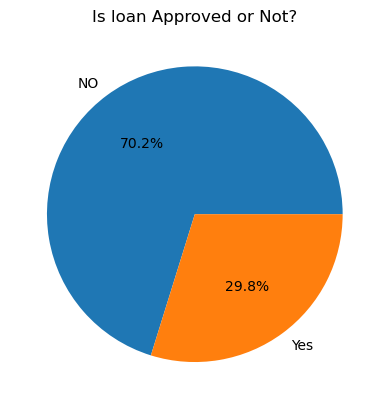

In [19]:
# Checked the distribution of target column
classes_count = df["Loan_Approved"].value_counts()

plt.pie(classes_count, labels = ["NO", "Yes"], autopct="%1.1f%%")
plt.title("Is loan Approved or Not?")

In [20]:
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


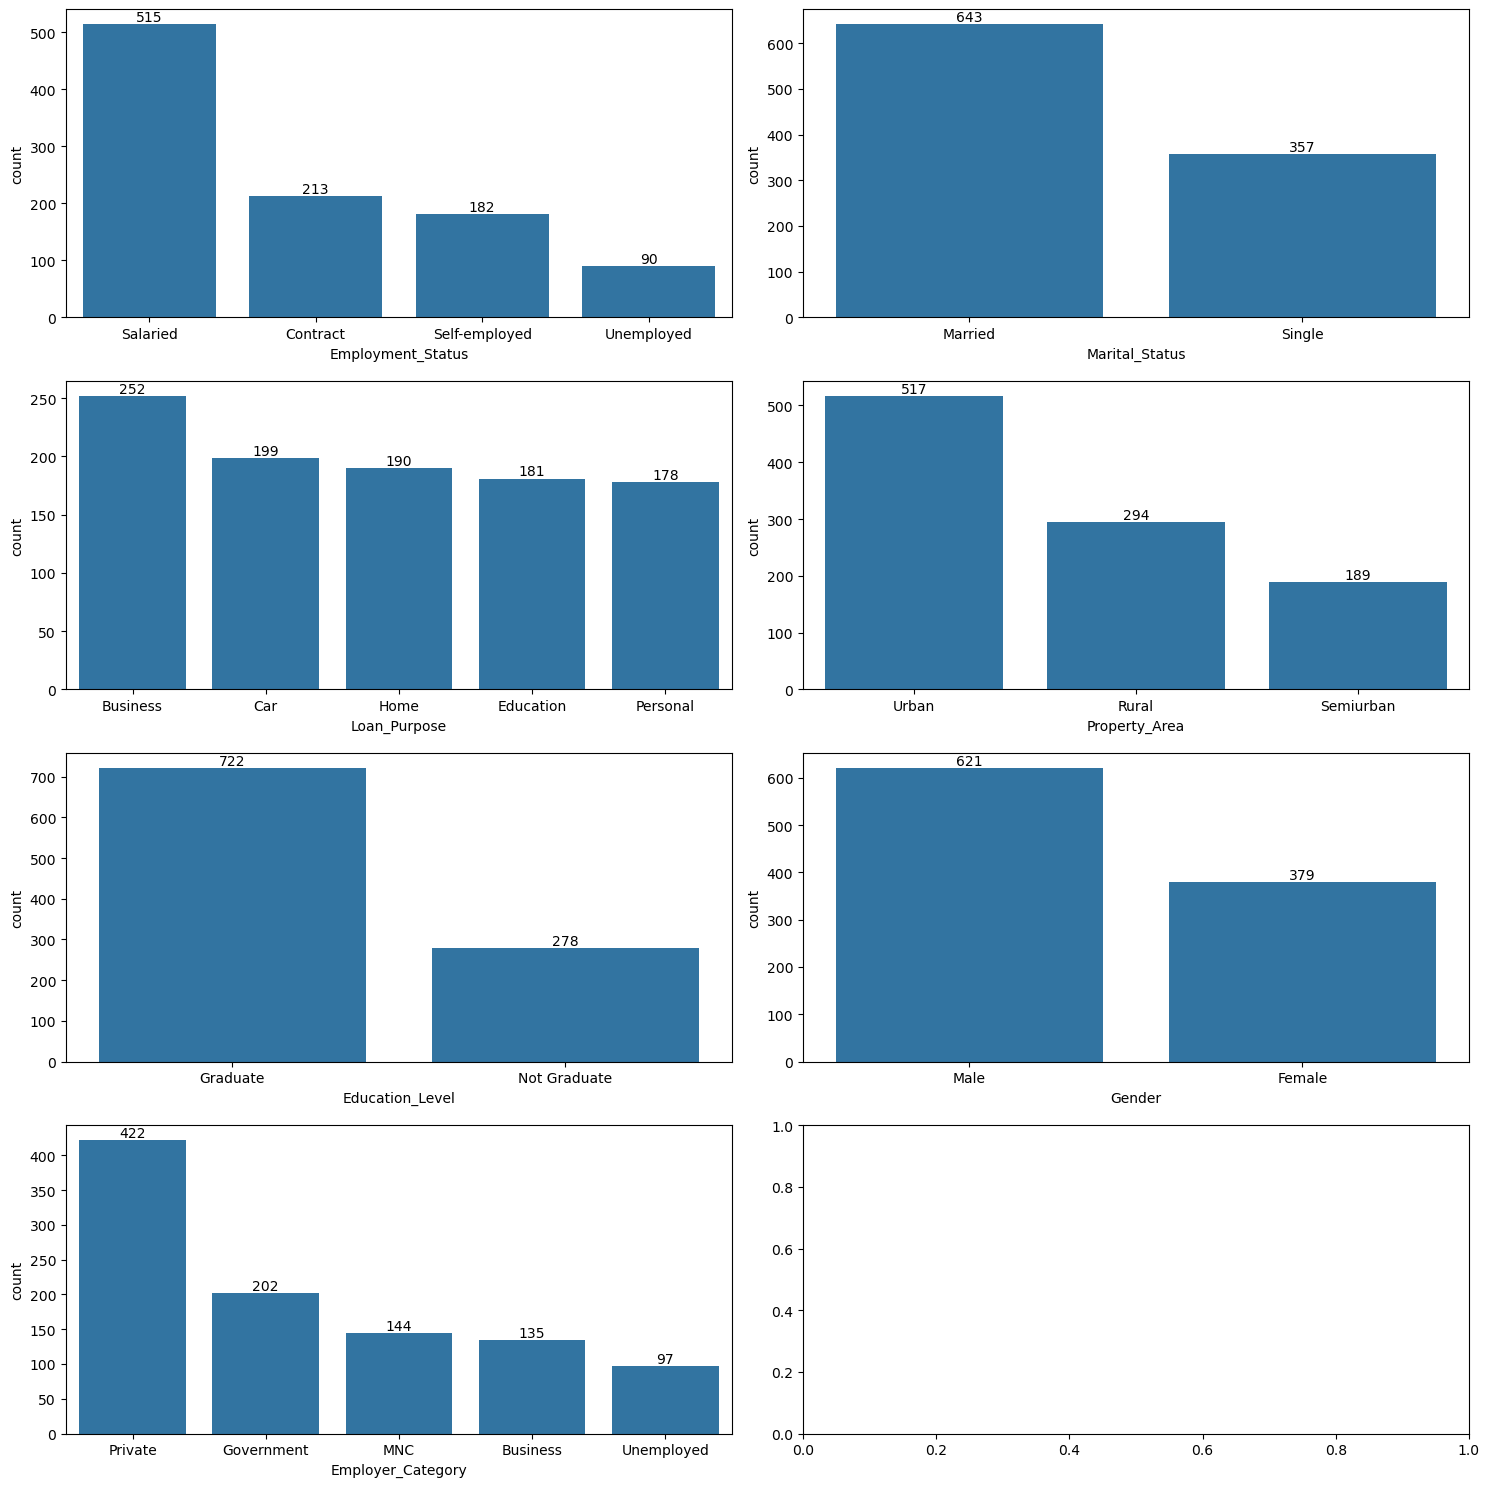

In [66]:
#distribution of feature columns
bar_feature_col = ["Employment_Status", "Marital_Status", "Loan_Purpose", "Property_Area", "Education_Level", "Gender", "Employer_Category"]

fig,ax = plt.subplots(4,2, figsize = (15,15))
count = 0
for i in range(4):
    for j in range(2):
        if (count < len(bar_feature_col)):
            
            feature = bar_feature_col[count]
            feaure_stat_count = df[feature].value_counts()
            axes = sns.barplot(feaure_stat_count,ax = ax[i][j])
            axes.bar_label(axes.containers[0])
            

        count = count + 1
fig.tight_layout()
# emp_stat_count = df["Loan_Purpose"].value_counts()
# ax = sns.barplot(emp_stat_count)
# ax.bar_label(ax.containers[0])